# NB02 — Validación del pipeline sobre un estudio real

## Propósito

Antes de lanzar la extracción masiva sobre 5.000 estudios (decenas de minutos de GPU), validamos el pipeline completo sobre **un único estudio real** de VinDr-Mammo. Esto sirve para detectar errores ahora, no después de 45 minutos perdidos.

El pipeline tiene 4 etapas:

1. **DICOM → tensor preprocesado**: lectura del archivo, ajuste de píxel, alineación por centroide, normalización tipo Mirai, redimensionado.
2. **Backbone → embeddings**: pasar las 4 vistas por el backbone congelado, obtener Punto A.
3. **Cálculo de Punto B**: aplicar stretch y calcular `|L − R|` por par bilateral.
4. **Reducción GAP+GMP**: convertir cada embedding (1, 512, 52, 64) en un vector (1, 1024).

Si todas las etapas dan shapes y rangos coherentes, podemos lanzar el NB03 con confianza.

In [1]:
import os, sys, time
import numpy as np
import pandas as pd
import torch
import cv2
import pydicom

# Raíz del proyecto: por defecto, la carpeta padre de notebooks/.
# Sobrescribible con la variable de entorno TFM_PROJECT_ROOT.
BASE      = os.environ.get('TFM_PROJECT_ROOT',
                           os.path.abspath(os.path.join(os.getcwd(), '..')))
ASYMMIRAI = os.path.join(BASE, 'AsymMirai')
DATA      = os.path.join(BASE, 'Data', 'vindr-mammo')
WEIGHTS   = os.path.join(ASYMMIRAI, 'snapshots', 'trained_asymmirai.pt')
IMG_DIR   = os.path.join(DATA, 'images')
BREAST_CSV = os.path.join(DATA, 'breast-level_annotations.csv')

sys.path.insert(0, ASYMMIRAI)
sys.path.insert(0, os.path.join(ASYMMIRAI, 'asymmetry_model'))

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## 1. Cargar AsymMirai y extraer los parámetros de stretch

El modelo se congela (no entrenamos nada) y guardamos a parte los `cc_stretch_params` y `mlo_stretch_params`, que son **vectores de 512 valores aprendidos por canal** que el modelo aplica antes de comparar L con R. Sin estos pesos el Punto B no sería fiel a lo que AsymMirai computa.

In [2]:
model = torch.load(WEIGHTS, map_location=DEVICE, weights_only=False)
model.eval()
for p in model.parameters():
    p.requires_grad = False

ALIGN_SPACE = getattr(model, 'alignment_space', None)
USE_STRETCH = getattr(model, 'use_stretch', False)

print(f'alignment_space = {ALIGN_SPACE}    use_stretch = {USE_STRETCH}')

if USE_STRETCH:
    cc_stretch  = model.cc_stretch_params.detach()
    mlo_stretch = model.mlo_stretch_params.detach()
    print(f'cc_stretch_params  shape={tuple(cc_stretch.shape)}  rango=[{cc_stretch.min():.3f}, {cc_stretch.max():.3f}]')
    print(f'mlo_stretch_params shape={tuple(mlo_stretch.shape)} rango=[{mlo_stretch.min():.3f}, {mlo_stretch.max():.3f}]')
else:
    cc_stretch = mlo_stretch = None

c:\Users\victo\miniconda3\envs\tfm\Lib\site-packages\torch\serialization.py:1782: SourceChangeWarning: source code of class 'mirai_localized_dif_head.LocalizedDifModel' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  _check_container_source(*data)
c:\Users\victo\miniconda3\envs\tfm\Lib\site-packages\torch\serialization.py:1782: SourceChangeWarning: source code of class 'torch.nn.modules.container.Sequential' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  _check_container_source(*data)


alignment_space = None    use_stretch = True
cc_stretch_params  shape=(512,)  rango=[-0.000, 4.586]
mlo_stretch_params shape=(512,) rango=[-0.000, 5.306]


## 2. Pipeline DICOM → tensor preprocesado

Cada DICOM pasa por estas transformaciones (en este orden):

### 2.1. `load_dicom`
- Lee el archivo y obtiene la matriz de píxeles.
- Aplica la transformación lineal `slope*p + intercept` (estándar DICOM para llevar los píxeles a unidades físicas).
- Si hay metadatos de Window/Level (centro y ancho de la ventana de visualización), recorta el rango de píxeles a ese intervalo. Esto enfoca el rango clínicamente relevante.
- Si la foto está invertida (`PhotometricInterpretation == 'MONOCHROME1'`, fondo claro), la invierte para que el fondo quede oscuro.

### 2.2. `align_by_centroid`
- Calcula el centroide del tejido mamario (umbral simple con la media de la imagen).
- Traslada la imagen para que el centroide quede en el centro del campo de visión.
- **Por qué**: las mamografías pueden venir con la mama pegada a uno de los bordes; centrarla reduce variabilidad espuria.

### 2.3. Resize bilineal a (1664, 2048)
El backbone fue entrenado a este tamaño exacto. Si cambiamos, los embeddings serán inútiles.

### 2.4. Normalización tipo Mirai
`(img - 7699.5) / 11765.06` con la media y desviación de Mirai. Sin esto los píxeles no caen en el rango con el que el backbone fue entrenado.

### 2.5. Triplicar canales y añadir dimensión batch
Resultado: tensor `(1, 3, 1664, 2048)` listo para el backbone.

In [3]:
MIRAI_MEAN = 7699.5
MIRAI_STD  = 11765.06
TARGET_H, TARGET_W = 1664, 2048

def load_dicom(path):
    ds = pydicom.dcmread(path)
    pixels = ds.pixel_array.astype(np.float32)
    # Transformación lineal estándar DICOM
    pixels = pixels * float(getattr(ds, 'RescaleSlope', 1)) + float(getattr(ds, 'RescaleIntercept', 0))
    # Window/Level si está disponible
    if hasattr(ds, 'WindowCenter') and hasattr(ds, 'WindowWidth'):
        wc = float(ds.WindowCenter[0]) if hasattr(ds.WindowCenter, '__iter__') else float(ds.WindowCenter)
        ww = float(ds.WindowWidth[0])  if hasattr(ds.WindowWidth,  '__iter__') else float(ds.WindowWidth)
        pixels = np.clip(pixels, wc-ww/2, wc+ww/2)
    # Invertir si fondo claro
    if getattr(ds, 'PhotometricInterpretation', '') == 'MONOCHROME1':
        pixels = pixels.max() - pixels
    return pixels

def align_by_centroid(img):
    h, w = img.shape
    mask = (img > img.mean()).astype(np.uint8)
    M = cv2.moments(mask)
    if M['m00'] == 0:
        return img  # imagen vacía o casi vacía: no la movemos
    cy, cx = int(M['m01']/M['m00']), int(M['m10']/M['m00'])
    M_aff = np.float32([[1, 0, w//2-cx], [0, 1, h//2-cy]])
    return cv2.warpAffine(img, M_aff, (w, h), borderValue=0)

def preprocess_view(dcm_path):
    img = load_dicom(dcm_path)
    img = align_by_centroid(img)
    img = cv2.resize(img, (TARGET_W, TARGET_H), interpolation=cv2.INTER_LINEAR)
    img = (img - MIRAI_MEAN) / MIRAI_STD
    img = np.stack([img, img, img], axis=0)[None, ...]   # (1, 3, H, W)
    return torch.from_numpy(img).float()

print('Funciones de preprocesado definidas.')

Funciones de preprocesado definidas.


## 3. Cargar el CSV de etiquetas y construir la etiqueta a nivel estudio

`breast-level_annotations.csv` trae 4 filas por estudio (una por L/R × CC/MLO). El BI-RADS está asignado a la **mama**, no a la vista, así que CC y MLO de la misma mama típicamente comparten BI-RADS.

Agregamos al **nivel estudio** con el max BI-RADS de las 4 vistas: si cualquier mama es sospechosa (BI-RADS ≥ 4), el estudio se etiqueta sospechoso.

El parser del BI-RADS convierte el formato string (`'BI-RADS 4'`) a entero (`4`).

In [4]:
df = pd.read_csv(BREAST_CSV)
print(f'Filas: {len(df):,}   Columnas: {df.columns.tolist()}')

def parse_birads(v):
    if isinstance(v, str):
        s = v.replace('BI-RADS', '').replace('BIRADS', '').strip()
        try: return int(s)
        except: return np.nan
    return int(v) if not pd.isna(v) else np.nan

df['birads_int'] = df['breast_birads'].apply(parse_birads)

study_agg = df.groupby('study_id').agg(
    max_birads = ('birads_int', 'max'),
    split      = ('split', 'first'),
).reset_index()
study_agg['y_estudio'] = (study_agg['max_birads'] >= 4).astype(int)

print(f'\nEstudios totales: {len(study_agg)}')
print(f'Distribución de max BI-RADS por estudio: {study_agg.max_birads.value_counts().sort_index().to_dict()}')
print(f'Etiqueta y_estudio=1 (BI-RADS ≥ 4): {study_agg.y_estudio.sum()} estudios ({100*study_agg.y_estudio.mean():.2f}%)')

Filas: 20,000   Columnas: ['study_id', 'series_id', 'image_id', 'laterality', 'view_position', 'height', 'width', 'breast_birads', 'breast_density', 'split']

Estudios totales: 5000
Distribución de max BI-RADS por estudio: {1: 2515, 2: 1568, 3: 436, 4: 368, 5: 113}
Etiqueta y_estudio=1 (BI-RADS ≥ 4): 481 estudios (9.62%)


## 4. Elegir un estudio positivo para validar

Cogemos uno con max BI-RADS ≥ 4 para verificar que el cálculo de asimetría también funciona en un caso "interesante". El resultado de UN estudio no es informativo del rendimiento; solo verifica que el pipeline no se rompe.

In [5]:
estudios_pos = study_agg[study_agg.y_estudio == 1]['study_id'].tolist()
study_id = estudios_pos[0]
max_b = int(study_agg[study_agg.study_id == study_id].max_birads.iloc[0])
print(f'Estudio elegido: {study_id}    max BI-RADS = {max_b}')

Estudio elegido: 003700f3c960e0b9bca2b8437c3dbf05    max BI-RADS = 4


## 5. Localizar las 4 vistas en disco

Estructura real: `Data\vindr-mammo\images\{study_id}\{image_id}.dicom`. Construimos un diccionario `(laterality, view) → path` y verificamos que las 4 existen.

In [6]:
df_study = df[df.study_id == study_id]
print(df_study[['image_id', 'laterality', 'view_position', 'breast_birads']])

vistas = {}
for _, row in df_study.iterrows():
    k = (row['laterality'], row['view_position'])
    vistas[k] = os.path.join(IMG_DIR, study_id, f'{row["image_id"]}.dicom')

print('\nVerificación de existencia en disco:')
for k, p in vistas.items():
    print(f'  {"✓" if os.path.isfile(p) else "✗"}  {k}: {p}')

assert all(os.path.isfile(p) for p in vistas.values()), 'Faltan vistas'

                              image_id laterality view_position breast_birads
9744  51b47f9024ccad1356354f56ac916f29          L            CC     BI-RADS 4
9745  3944b33b99c98e763763b9da54b4f41c          L           MLO     BI-RADS 4
9746  17c3d032d611eb3d1baf3434d62483a1          R            CC     BI-RADS 1
9747  552a67df6d68b8f9498db7cadd23b0e0          R           MLO     BI-RADS 1

Verificación de existencia en disco:
  ✓  ('L', 'CC'): c:\Users\victo\Documents\TFM\Proyecto\Data\vindr-mammo\images\003700f3c960e0b9bca2b8437c3dbf05\51b47f9024ccad1356354f56ac916f29.dicom
  ✓  ('L', 'MLO'): c:\Users\victo\Documents\TFM\Proyecto\Data\vindr-mammo\images\003700f3c960e0b9bca2b8437c3dbf05\3944b33b99c98e763763b9da54b4f41c.dicom
  ✓  ('R', 'CC'): c:\Users\victo\Documents\TFM\Proyecto\Data\vindr-mammo\images\003700f3c960e0b9bca2b8437c3dbf05\17c3d032d611eb3d1baf3434d62483a1.dicom
  ✓  ('R', 'MLO'): c:\Users\victo\Documents\TFM\Proyecto\Data\vindr-mammo\images\003700f3c960e0b9bca2b8437c3dbf05\5

## 6. Preprocesar las 4 vistas y pasarlas por el backbone

Cada vista pasa por el preprocesado y luego por `model.backbone(...)`. La salida es el embedding `(1, 512, 52, 64)` por vista. **Esto es el Punto A**: los 4 embeddings, uno por vista, sin asimetría aplicada.

In [7]:
t0 = time.time()
l_cc  = preprocess_view(vistas[('L', 'CC')]).to(DEVICE)
r_cc  = preprocess_view(vistas[('R', 'CC')]).to(DEVICE)
l_mlo = preprocess_view(vistas[('L', 'MLO')]).to(DEVICE)
r_mlo = preprocess_view(vistas[('R', 'MLO')]).to(DEVICE)
print(f'Preprocesado 4 vistas: {time.time()-t0:.2f}s')

t0 = time.time()
with torch.no_grad():
    emb_l_cc  = model.backbone(l_cc)
    emb_r_cc  = model.backbone(r_cc)
    emb_l_mlo = model.backbone(l_mlo)
    emb_r_mlo = model.backbone(r_mlo)
print(f'Backbone (4 vistas): {time.time()-t0:.2f}s')

for nm, t in [('L_CC', emb_l_cc), ('R_CC', emb_r_cc), ('L_MLO', emb_l_mlo), ('R_MLO', emb_r_mlo)]:
    print(f'  PUNTO A — emb_{nm}: shape={tuple(t.shape)}')

Preprocesado 4 vistas: 0.41s
Backbone (4 vistas): 0.13s
  PUNTO A — emb_L_CC: shape=(1, 512, 52, 64)
  PUNTO A — emb_R_CC: shape=(1, 512, 52, 64)
  PUNTO A — emb_L_MLO: shape=(1, 512, 52, 64)
  PUNTO A — emb_R_MLO: shape=(1, 512, 52, 64)


## 7. Calcular el Punto B (asimetría bilateral con stretch)

El cálculo replica **los dos primeros pasos** de lo que `LocalizedDifModel.asymmetry_metric()` (la función `hybrid_asymmetry` del repo oficial) hace internamente:

1. Aplica los pesos por canal aprendidos: `L_stretched = stretch ⊙ L_emb`, lo mismo con R.
2. Calcula la diferencia absoluta: `asym = |L_stretched − R_stretched|`.

Lo que el código oficial hace **después** y que nosotros NO replicamos: (3) MaxPool2D flexible con kernel (10, 12) y stride (1, 1), (4) `torch.norm(dim=-3)` que colapsa los 512 canales en una norma L2 por posición espacial (dejando un mapa 2D), y (5) máximo global sobre ese mapa 2D, devolviendo un escalar. El score escalar final de AsymMirai surge de promediar el resultado de CC y MLO, normalizarlo con (mean=40, std=10) aprendidos y aplicar sigmoide.

**Divergencia deliberada:** preservamos el mapa de asimetría con sus 512 canales y lo reducimos con GAP+GMP igual que el Punto A (ver siguiente celda). Esto produce un vector de 1.024 dimensiones por mapa, sustancialmente más informativo que el escalar que el modelo original produce. El objetivo no es reproducir el score de riesgo a 1-5 años de AsymMirai (no podríamos: no tenemos seguimiento longitudinal en VinDr), sino aprovechar las representaciones internas de asimetría para una tarea distinta (clasificación binaria BI-RADS).

El stretch es **distinto por vista** (CC tiene sus pesos, MLO los suyos), porque el modelo aprendió que la información discriminativa de la asimetría se distribuye distinto en las dos proyecciones.

In [8]:
def compute_asym(left_emb, right_emb, stretch_params=None):
    """
    Calcula |L − R| sobre los embeddings, aplicando opcionalmente los pesos de stretch
    canal a canal antes de la sustracción.
    """
    if stretch_params is not None:
        # broadcasting: stretch (C,) → (1, C, 1, 1) para multiplicar por (B, C, H, W)
        sp = stretch_params.view(1, -1, 1, 1).to(left_emb.device)
        left_emb  = sp * left_emb
        right_emb = sp * right_emb
    return torch.abs(left_emb - right_emb)

with torch.no_grad():
    asym_cc  = compute_asym(emb_l_cc,  emb_r_cc,  cc_stretch  if USE_STRETCH else None)
    asym_mlo = compute_asym(emb_l_mlo, emb_r_mlo, mlo_stretch if USE_STRETCH else None)

print(f'PUNTO B — asym_CC : shape={tuple(asym_cc.shape)}   media={asym_cc.mean():.4f}   max={asym_cc.max():.4f}')
print(f'PUNTO B — asym_MLO: shape={tuple(asym_mlo.shape)}  media={asym_mlo.mean():.4f}  max={asym_mlo.max():.4f}')

PUNTO B — asym_CC : shape=(1, 512, 52, 64)   media=0.0009   max=1.8370
PUNTO B — asym_MLO: shape=(1, 512, 52, 64)  media=0.0009  max=1.2684


## 8. Reducción GAP + GMP — la misma para los dos puntos

**Decisión clave de diseño:** aplicamos la **misma reducción a Punto A y Punto B**. Si usáramos GAP solo para A y GMP solo para B, no sabríamos si las diferencias en AUC vienen del contenido informativo o del método de pooling. Manteniendo el pooling constante, las diferencias reflejan contenido.

**Cada vector pooleado tiene 1024 dims** (512 GAP + 512 GMP) — un vector por vista o por par bilateral.

In [9]:
def pool_features(x):
    """
    x: tensor (B, C, H, W). Devuelve (B, 2C) con [GAP | GMP] concatenados por canal.
    GAP captura magnitud media (información global), GMP captura el pico (información local).
    """
    gap = x.mean(dim=(-2, -1))   # (B, C)
    gmp = x.amax(dim=(-2, -1))   # (B, C)
    return torch.cat([gap, gmp], dim=1)

feat_l_cc     = pool_features(emb_l_cc)
feat_r_cc     = pool_features(emb_r_cc)
feat_l_mlo    = pool_features(emb_l_mlo)
feat_r_mlo    = pool_features(emb_r_mlo)
feat_asym_cc  = pool_features(asym_cc)
feat_asym_mlo = pool_features(asym_mlo)

print(f'Punto A — feat_L_CC   shape={tuple(feat_l_cc.shape)}    rango=[{feat_l_cc.min():.2f}, {feat_l_cc.max():.2f}]')
print(f'Punto A — feat_R_CC   shape={tuple(feat_r_cc.shape)}    rango=[{feat_r_cc.min():.2f}, {feat_r_cc.max():.2f}]')
print(f'Punto A — feat_L_MLO  shape={tuple(feat_l_mlo.shape)}   rango=[{feat_l_mlo.min():.2f}, {feat_l_mlo.max():.2f}]')
print(f'Punto A — feat_R_MLO  shape={tuple(feat_r_mlo.shape)}   rango=[{feat_r_mlo.min():.2f}, {feat_r_mlo.max():.2f}]')
print(f'Punto B — feat_asym_CC  shape={tuple(feat_asym_cc.shape)}   rango=[{feat_asym_cc.min():.3f}, {feat_asym_cc.max():.3f}]')
print(f'Punto B — feat_asym_MLO shape={tuple(feat_asym_mlo.shape)}  rango=[{feat_asym_mlo.min():.3f}, {feat_asym_mlo.max():.3f}]')

Punto A — feat_L_CC   shape=(1, 1024)    rango=[0.00, 2.73]
Punto A — feat_R_CC   shape=(1, 1024)    rango=[0.00, 2.70]
Punto A — feat_L_MLO  shape=(1, 1024)   rango=[0.00, 2.70]
Punto A — feat_R_MLO  shape=(1, 1024)   rango=[0.00, 2.70]
Punto B — feat_asym_CC  shape=(1, 1024)   rango=[0.000, 1.837]
Punto B — feat_asym_MLO shape=(1, 1024)  rango=[0.000, 1.268]


## 9. Construcción de los inputs según configuración

Estos 6 vectores de 1024 dims permiten construir las tres configuraciones del trabajo, simplemente concatenando los apropiados:

- **E-A (estudio, Punto A)** = concat(L-CC, R-CC, L-MLO, R-MLO) → **4096 dims**.
- **E-B (estudio, Punto B)** = concat(asym-CC, asym-MLO) → **2048 dims**.
- **M-A (mama, Punto A)** = un vector por mama = concat(CC, MLO) de esa mama → **2048 dims**.

Esta separación entre extracción (cara, en GPU) y construcción de input (barata, en RAM) es la clave de la arquitectura: extraemos una sola vez y reconstruimos las configuraciones que queramos.

In [10]:
x_E_A     = torch.cat([feat_l_cc, feat_r_cc, feat_l_mlo, feat_r_mlo], dim=1)
x_E_B     = torch.cat([feat_asym_cc, feat_asym_mlo], dim=1)
x_M_A_L   = torch.cat([feat_l_cc, feat_l_mlo], dim=1)
x_M_A_R   = torch.cat([feat_r_cc, feat_r_mlo], dim=1)

print(f'E-A (estudio, Punto A): shape={tuple(x_E_A.shape)}    ← 4 vistas × 1024 dims')
print(f'E-B (estudio, Punto B): shape={tuple(x_E_B.shape)}    ← 2 pares × 1024 dims')
print(f'M-A izquierda (mama):   shape={tuple(x_M_A_L.shape)}     ← 2 vistas × 1024 dims')
print(f'M-A derecha   (mama):   shape={tuple(x_M_A_R.shape)}     ← 2 vistas × 1024 dims')

E-A (estudio, Punto A): shape=(1, 4096)    ← 4 vistas × 1024 dims
E-B (estudio, Punto B): shape=(1, 2048)    ← 2 pares × 1024 dims
M-A izquierda (mama):   shape=(1, 2048)     ← 2 vistas × 1024 dims
M-A derecha   (mama):   shape=(1, 2048)     ← 2 vistas × 1024 dims


## 10. Visualización de las etapas del preprocesado

Añadido en Hito 3 a petición de la tutora (punto 13 del feedback).

Para ilustrar de forma visual las transformaciones que sufre una vista DICOM antes de entrar al backbone, se instrumenta el pipeline de preprocesado para capturar la imagen en cada etapa intermedia. La figura resultante acompaña a la Ilustración 4 de la memoria (sección 4.6.1) mostrando el efecto real de cada paso sobre una vista mamográfica.

Las cinco etapas visualizadas son:

1. **DICOM crudo** — matriz de píxeles tras `pydicom.dcmread` y aplicación del `RescaleSlope`/`RescaleIntercept` estándar.
2. **Window/Level + fotometría** — recorte al rango clínicamente relevante `[WC−WW/2, WC+WW/2]` e inversión de MONOCHROME1 si aplica.
3. **Alineación por centroide** — traslación de la imagen para que el centroide del tejido mamario quede en el centro del campo de visión.
4. **Redimensionado** — interpolación bilineal a `(1664, 2048)`, el tamaño de entrada del backbone AsymMirai.
5. **Normalización tipo Mirai** — resta la media y divide por la desviación estándar heredadas del entrenamiento original de Mirai sobre EMBED.


Vista de ejemplo: ('L', 'CC')  →  51b47f9024ccad1356354f56ac916f29.dicom

Etapa                           Shape               Rango                       dtype
──────────────────────────────────────────────────────────────────────────────────────────
  1_dicom_crudo                 (3518, 2800)        [0.000, 2624.000]           float32
  2_window_level                (3518, 2800)        [893.000, 2393.000]         float32
  3_alineacion                  (3518, 2800)        [893.000, 2336.000]         float32
  4_redimensionado              (1664, 2048)        [893.000, 2301.229]         float32
  5_normalizado                 (1664, 2048)        [-0.579, -0.459]            float32


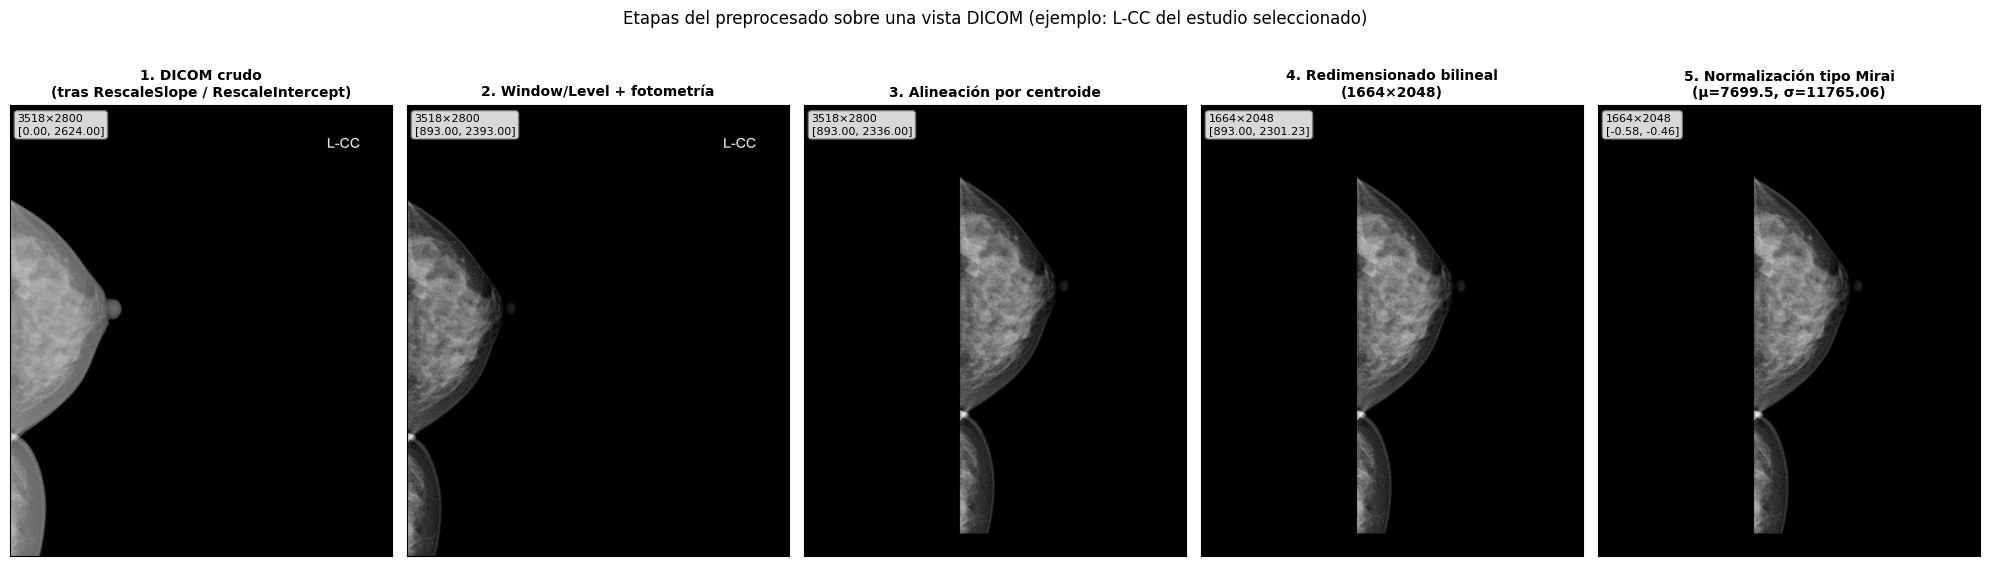


Guardado: c:\Users\victo\Documents\TFM\Proyecto\outputs\Features\preprocesado_etapas.png


In [11]:
# ─────────────────────────────────────────────────────────────────────
# Función instrumentada: captura la imagen en cada etapa del preprocesado.
# Reproduce exactamente el flujo de preprocess_view (sección 2) pero
# devuelve un dict con la imagen intermedia en cada paso.
# ─────────────────────────────────────────────────────────────────────
def preprocess_view_with_stages(dcm_path):
    ds = pydicom.dcmread(dcm_path)
    stages = {}

    # 1) DICOM crudo + RescaleSlope/Intercept
    pixels = ds.pixel_array.astype(np.float32)
    pixels = pixels * float(getattr(ds, 'RescaleSlope', 1)) + float(getattr(ds, 'RescaleIntercept', 0))
    stages['1_dicom_crudo'] = pixels.copy()

    # 2) Window/Level (si disponible) + fotometría
    if hasattr(ds, 'WindowCenter') and hasattr(ds, 'WindowWidth'):
        wc = float(ds.WindowCenter[0]) if hasattr(ds.WindowCenter, '__iter__') else float(ds.WindowCenter)
        ww = float(ds.WindowWidth[0])  if hasattr(ds.WindowWidth,  '__iter__') else float(ds.WindowWidth)
        pixels = np.clip(pixels, wc-ww/2, wc+ww/2)
    if getattr(ds, 'PhotometricInterpretation', '') == 'MONOCHROME1':
        pixels = pixels.max() - pixels
    stages['2_window_level'] = pixels.copy()

    # 3) Alineación por centroide
    # Para visualización usamos una variante local con borderValue = valor de fondo
    # (mínimo tras W/L) en lugar del 0 hardcodeado en align_by_centroid. Esto evita
    # un artefacto visual del autoescalado de imshow: si el fondo tras W/L es 893
    # y warpAffine introduce nuevas zonas a 0, imshow reescala y el fondo original
    # pasa de verse negro a verse gris, generando un "recuadro gris fantasma" en
    # las etapas 3, 4 y 5. Con borderValue = min(pixels) el fondo queda uniforme.
    _bg = float(pixels.min())
    _h, _w = pixels.shape
    _mask = (pixels > pixels.mean()).astype(np.uint8)
    _M = cv2.moments(_mask)
    if _M['m00'] != 0:
        _cy = int(_M['m01']/_M['m00']); _cx = int(_M['m10']/_M['m00'])
        _M_aff = np.float32([[1,0,_w//2-_cx],[0,1,_h//2-_cy]])
        pixels = cv2.warpAffine(pixels, _M_aff, (_w, _h), borderValue=_bg)
    stages['3_alineacion'] = pixels.copy()

    # 4) Redimensionado bilineal
    pixels = cv2.resize(pixels, (TARGET_W, TARGET_H), interpolation=cv2.INTER_LINEAR)
    stages['4_redimensionado'] = pixels.copy()

    # 5) Normalización tipo Mirai
    pixels = (pixels - MIRAI_MEAN) / MIRAI_STD
    stages['5_normalizado'] = pixels.copy()

    return stages


# ─────────────────────────────────────────────────────────────────────
# Aplicar sobre la vista L-CC del estudio ya seleccionado en la sección 4
# ─────────────────────────────────────────────────────────────────────
_vista_ejemplo = ('L', 'CC')
_dcm_path_ejemplo = vistas[_vista_ejemplo]
print(f'Vista de ejemplo: {_vista_ejemplo}  →  {os.path.basename(_dcm_path_ejemplo)}')

_stages = preprocess_view_with_stages(_dcm_path_ejemplo)

# Resumen tabular
print(f'\n{"Etapa":<32}{"Shape":<20}{"Rango":<28}{"dtype"}')
print('─' * 90)
for name, img in _stages.items():
    r = f'[{img.min():.3f}, {img.max():.3f}]'
    print(f'  {name:<30}{str(img.shape):<20}{r:<28}{img.dtype}')

# ─────────────────────────────────────────────────────────────────────
# Figura 1×5 mostrando la imagen en cada etapa
# ─────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

_titles = {
    '1_dicom_crudo':     '1. DICOM crudo\n(tras RescaleSlope / RescaleIntercept)',
    '2_window_level':    '2. Window/Level + fotometría',
    '3_alineacion':      '3. Alineación por centroide',
    '4_redimensionado':  f'4. Redimensionado bilineal\n({TARGET_H}×{TARGET_W})',
    '5_normalizado':     '5. Normalización tipo Mirai\n(μ=7699.5, σ=11765.06)',
}

fig, axes = plt.subplots(1, 5, figsize=(20, 5.5))
for ax, (key, img) in zip(axes, _stages.items()):
    ax.imshow(img, cmap='gray', aspect='auto')
    ax.set_title(_titles[key], fontsize=10, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    _txt = f'{img.shape[0]}×{img.shape[1]}\n[{img.min():.2f}, {img.max():.2f}]'
    ax.text(0.02, 0.98, _txt, transform=ax.transAxes,
            fontsize=8, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='gray'))

fig.suptitle(f'Etapas del preprocesado sobre una vista DICOM (ejemplo: {_vista_ejemplo[0]}-{_vista_ejemplo[1]} del estudio seleccionado)',
             fontsize=12, y=1.02)
plt.tight_layout()

# Guardar en BASE/outputs/Features/ (mismo dir que el resto de artefactos)
_features_dir = os.path.join(BASE, 'outputs', 'Features')
os.makedirs(_features_dir, exist_ok=True)
_out_path = os.path.join(_features_dir, 'preprocesado_etapas.png')
plt.savefig(_out_path, dpi=140, bbox_inches='tight')
plt.show()
print(f'\nGuardado: {_out_path}')


## 11. Resumen

Si todo ha llegado hasta aquí sin errores:

- ✓ Modelo cargado, backbone congelado.
- ✓ Stretch params extraídos (vectores de 512 para CC y para MLO).
- ✓ Pipeline DICOM → tensor (1, 3, 1664, 2048) funcional.
- ✓ Backbone produce embedding (1, 512, 52, 64) por vista.
- ✓ Cálculo de asimetría replicado con stretch.
- ✓ Reducción GAP+GMP a vectores de 1024 dims.
- ✓ Inputs de las 3 configuraciones construidos con los shapes esperados.

## Siguiente paso

`03_extraccion_masiva.ipynb` — repetir esto sobre los 5.000 estudios y guardar el tensor `X_view (N, 4, 1024)` y `X_asym (N, 2, 1024)` en disco.